In [1]:
import jax
import jax.numpy as jnp
import immrax as irx
from immrax.taylor import BasicTMFlowpipeGenerator
import matplotlib.pyplot as plt

jax.config.update('jax_enable_x64', True)

class HarmonicOscillator(irx.System):
    def __init__(self):
        self.evolution = "continuous"
        self.xlen = 2

    def f(self, t, x):
        # return jnp.array([x[1], -x[0]])
        # VanderPol Oscillator
        mu = 1.0
        return jnp.array([x[1], mu * (1 - x[0] ** 2) * x[1] - x[0]])



In [2]:
sys = HarmonicOscillator()
t0 = 0.0
tf = 7.0
ix0 = irx.icentpert([-2, 0.0], [0.1, 0.0])
tmx = irx.taylor_model_identity(ix0, order=2)

fpg = BasicTMFlowpipeGenerator(sys)
dt = 0.05

delta = 1e-4
eps = 1e-2


@jax.jit
def gen_flowpipe(t0, tf, tmx, dt, delta, eps):
    return fpg.generate_flowpipe(
        t0, tf, tmx, dt_max=dt, t_order=5, delta=delta, eps=eps
    )


In [3]:
# fp, times = irx.utils.run_times(10, gen_flowpipe, t0, tf, tmx, 0.01, 1e-5, 1e-5)
fp = gen_flowpipe (t0, tf, tmx, 0.05, 1e-4, 1e-1)
times = jnp.array([0.])

print(f"nsteps: {fp.nsteps}, success: {fp.success}, med time {jnp.median(times)}")

nsteps: 41, success: False, med time 0.0


In [4]:
def mc_sim(x0):
    return sys.compute_trajectory(t0, tf, x0, (), dt)


In [5]:
print(fp, fp.nsteps)
hulls = fp.interval_hulls()[:fp.nsteps]
print(hulls.shape)
final_tm = fp(7.)
print(final_tm(final_tm.center))
print(final_tm.interval_hull())

<immrax.taylor.algorithms.base.TMFlowpipe object at 0x7fc4b8514890> 41
(41, 2)
[ -1867.30622694 -12681.66124785] <= x <= [ -1839.74700226 -12654.10202317]
[ -3865.92111361 -19192.99362715] <= x <= [ -171.37582073 -5015.032506  ]


AttributeError: 'MultiPolygon' object has no attribute 'exterior'

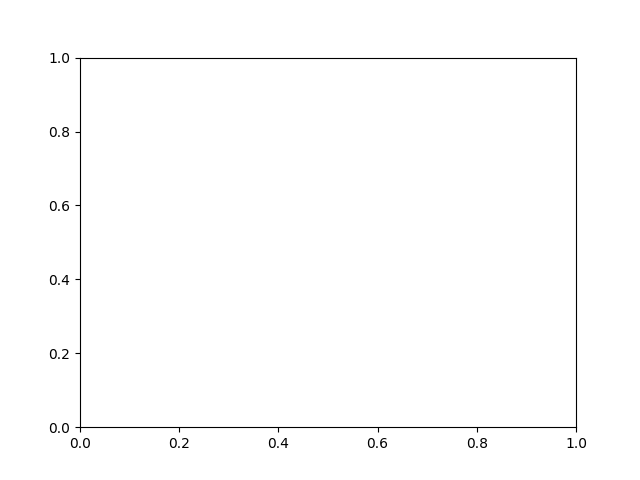

In [6]:
%matplotlib widget

fig, ax = plt.subplots()
ics = irx.utils.gen_ics(final_tm.domain, 1000)
# print(final_tm.domain @ jnp.vstack(jnp.linspace(0,1,100)))
# ics = irx.interval(jnp.zeros((100, 2)), final_tm.domain[None,:] @ jnp.vstack(jnp.linspace(0,1,100)))
hulls = jax.vmap(final_tm.evaluate)(ics)
irx.utils.draw_iarrays(ax, hulls)

centers = jax.vmap(final_tm.evaluate_polynomial)(ics)
ax.scatter(centers[:,0], centers[:,1], s=1)

'MultiPolygon' object has no attribute 'exterior'
'MultiPolygon' object has no attribute 'exterior'
'MultiPolygon' object has no attribute 'exterior'
'MultiPolygon' object has no attribute 'exterior'
(100, 141, 2)


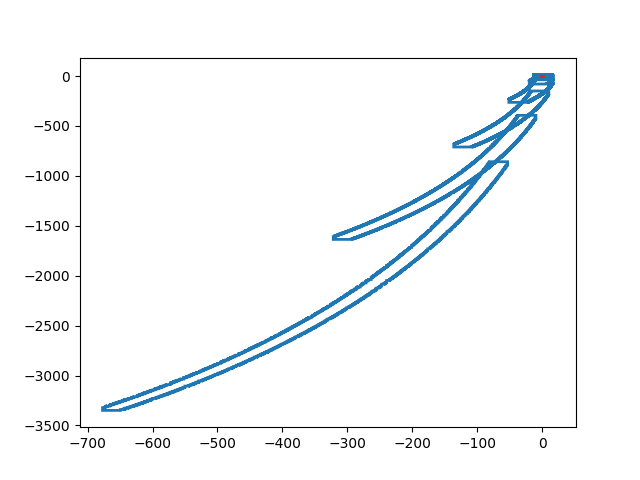

In [7]:
%matplotlib widget

fig, ax = plt.subplots()

mc_x0s = irx.utils.gen_ics(ix0, 100)
mc_trajs = jax.vmap(mc_sim)(mc_x0s)

PLOT_EVERY = 10
test_times = jnp.arange(t0, tf + dt, dt)[::PLOT_EVERY]
# irx.utils.draw_iarray(ax, tmx.interval_hull(), color="tab:red")

# irx.utils.draw_iarrays(ax, hulls[:fp.nsteps//2])
# irx.utils.draw_iarrays(ax, hulls[fp.nsteps//2:])

for t in test_times:
    spatial_tm = fp(t)
    # irx.utils.draw_iarray(ax, spatial_tm.interval_hull(), color="tab:blue")
    ics = irx.utils.gen_ics(spatial_tm.domain, 1000)
    hulls = jax.vmap(spatial_tm.evaluate)(ics)
    # centers = jax.vmap(final_tm.evaluate_polynomial)(ics)
    try :
        irx.utils.draw_iarrays(ax, hulls)
        # ax.scatter(centers[:,0], centers[:,1], s=1)
    except Exception as e :
        print(e)

mc_trajs = mc_trajs.to_convenience()
print(mc_trajs.ys.shape)
ax.scatter(
    mc_trajs.ys[:, ::PLOT_EVERY, 0],
    mc_trajs.ys[:, ::PLOT_EVERY, 1],
    color="tab:red",
    s=1,
)

plt.show()

